# Imports

In [863]:
# Install project dependencies when running in a hosted/online notebook (Colab, Kaggle, etc.).
# Locally, ModifiedNEAT is imported via PRJ_DIR on sys.path (see the next cell), so this is a no-op there.
try:
    import ModifiedNEAT  # noqa: F401
except ImportError:
    # TODO: point this at the real package source once it has one (PyPI release or the project's git repo)
    # !pip install ModifiedNEAT
    # !pip install git+https://github.com/<owner>/ModifiedNEAT.git
    pass


In [864]:
import os, sys
import ModifiedNEAT as meat
import ModifiedNEAT.nn as mnn
import ModifiedNEAT.optim as optim
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math
import random
import warnings

from torch import Tensor
from numpy import ndarray as CPUArray
from typing import Union
from copy import deepcopy
from matplotlib.pyplot import Axes
from numba.core.errors import NumbaPerformanceWarning

PRJ_DIR = os.path.dirname(os.path.dirname(os.getcwd()))
if PRJ_DIR not in sys.path: sys.path.insert(0, PRJ_DIR)
print(f"Project path = {PRJ_DIR}")

from ModifiedNEAT import Population, Config
from ModifiedNEAT.nn.base import NeatModule
from ModifiedNEAT.util.datetime import clock, eta
from ModifiedNEAT.util.fancy_text import CM, Fore

warnings.filterwarnings("ignore", category=NumbaPerformanceWarning)

Project path = /home/master/Desktop/repos/python/Modified-NEAT


In [865]:
DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DTYPE   = torch.float32
DEVICE, DTYPE

(device(type='cpu'), torch.float32)

In [866]:
INT_MAPPING = {
    torch.float16: torch.int16,
    torch.float32: torch.int32,
    torch.float64: torch.int64,
    torch.bfloat16: torch.int16,
}
FLOAT_MAPPING = {v: k for k, v in INT_MAPPING.items()}

def get_int_dtype(type: torch.dtype):
    return INT_MAPPING.get(type, torch.long)

def get_float_dtype(type: torch.dtype):
    return FLOAT_MAPPING.get(type, torch.double)

# Data creation

In [867]:
def create_data(
    records: int, classes: int, base: int = 2, reverse: bool = False, 
    normalize: bool = True, discrete: bool = False, randomize: bool = False,
    device: torch.device | str = 'cpu', dtype: torch.dtype = torch.float32
):
    _dtype = dtype if not discrete else get_int_dtype(dtype)
    labels = (
        torch.arange(records, device=device, dtype=get_int_dtype(dtype)) % classes
        if not randomize else
        torch.randint(0, classes, (records,), device=device, dtype=get_int_dtype(dtype))
    ).contiguous()
    enc_len = math.ceil(round(math.log(classes, base), 8))
    encodings = labels.to(_dtype).unsqueeze(-1).expand(labels.shape[0], enc_len).contiguous()
    # Compute base^i for each digit position i = 0, ..., enc_len-1 (least-significant first)
    powers = base ** torch.arange(enc_len, device=device, dtype=torch.int64)
    powers = (powers if reverse else powers.flip(0))
    # Extract each digit: floor(label / base^i) % base
    encodings = (torch.floor(encodings / powers) % base).to(_dtype)
    if normalize and not discrete: encodings = encodings / (base - 1)
    return encodings, labels

In [868]:
for t in create_data(20, 8, 2, False, True, False): print(f"{t}\n{t.shape} | '{t.device}' | '{t.dtype}'")

tensor([[0., 0., 0.],
        [0., 0., 1.],
        [0., 1., 0.],
        [0., 1., 1.],
        [1., 0., 0.],
        [1., 0., 1.],
        [1., 1., 0.],
        [1., 1., 1.],
        [0., 0., 0.],
        [0., 0., 1.],
        [0., 1., 0.],
        [0., 1., 1.],
        [1., 0., 0.],
        [1., 0., 1.],
        [1., 1., 0.],
        [1., 1., 1.],
        [0., 0., 0.],
        [0., 0., 1.],
        [0., 1., 0.],
        [0., 1., 1.]])
torch.Size([20, 3]) | 'cpu' | 'torch.float32'
tensor([0, 1, 2, 3, 4, 5, 6, 7, 0, 1, 2, 3, 4, 5, 6, 7, 0, 1, 2, 3],
       dtype=torch.int32)
torch.Size([20]) | 'cpu' | 'torch.int32'


In [869]:
def tensor_memory(tensor: Tensor):
    """
    :param tensor: PyTorch tensor
    :return: Memory in Megabytes
    """
    return tensor.numel() * tensor.element_size() / (1024 ** 2)

# View data

In [870]:
def _add_bit_dividers(axis: Axes, num_bits: int, color='gray', linewidth=0.6, alpha=0.7):
    """Draw thin vertical lines between each bit-column (pixel boundaries)."""
    for i in range(1, num_bits):
        axis.axvline(i - 0.5, color=color, linewidth=linewidth, alpha=alpha)

def show_image(image: Tensor, title: str = None, size: tuple[int, int] = None, cmap='binary',
               axis: Axes = None, show_dividers: bool = True, divider_color='black', divider_width=2):
    if image.ndim == 1: image = image.unsqueeze(-2)
    features, columns = image.shape[-2:]
    image = torch.stack([image for _ in range(columns)], dim=-2)
    if size is None: size = (360, 360)
    if image.ndim == 3: image = image.permute(1, 2, 0)
    elif image.ndim == 2: pass
    else: raise ValueError(f"Unsupported ndim")
    image = image.cpu()
    created_axis = axis is None
    if axis is None:
        _, axis = plt.subplots(1, 1, figsize=(size[0] * 0.01, size[1] * 0.01))
    axis.imshow(image, cmap=cmap)
    if show_dividers:
        _add_bit_dividers(axis, columns, color=divider_color, linewidth=divider_width)
    if title is not None:
        axis.set_title(title)
    axis.set_axis_off()
    if created_axis:
        plt.show()

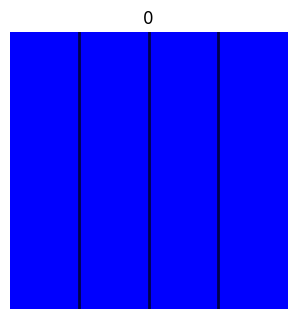

In [871]:
test_enc, test_lbl = [t[0] for t in create_data(records=1, classes=16, base=2)]
show_image(test_enc, test_lbl.item(), cmap='brg')

In [872]:
def show_batch(
    images: Tensor, predictions: Tensor = None, labels: Tensor = None, columns=8,
    size: tuple[int, int] = None, cmap='binary', no_axes=True,
    show_dividers: bool = True, divider_color='black', divider_width=2.0,
    compare: bool = False, base: int = 2, reverse: bool = False,
    normalize: bool = True, discrete: bool = False,
):
    # Only "compare" when we actually have predictions to turn into encodings
    compare_enabled = compare and predictions is not None

    def _to_visual(enc: Tensor, columns_: int) -> Tensor:
        if enc.ndim == 2: enc = enc.unsqueeze(-2)
        enc = torch.stack([enc for _ in range(columns_)], dim=-2)
        if enc.ndim == 4: enc = enc.permute(0, 2, 3, 1)
        elif enc.ndim == 3: pass
        else: raise ValueError(f"Unsupported ndim")
        return enc.cpu()

    # enc_len / columns_ (bit-width) comes from the raw encoding width, before visual expansion
    enc_len = images.shape[-1]
    columns_ = enc_len
    images_vis = _to_visual(images, columns_)

    if size is None: size = (720, 1080)

    predicted_vis = None
    if compare_enabled:
        # Reconstruct the predicted encodings the same way create_data does, so they're
        # directly visually comparable to the actual/expected encodings above them.
        _dtype = images.dtype if not discrete else get_int_dtype(images.dtype)
        pred_labels = predictions.to(images.device)
        pred_enc = pred_labels.to(_dtype).unsqueeze(-1).expand(pred_labels.shape[0], enc_len).contiguous()
        powers = base ** torch.arange(enc_len, device=images.device, dtype=torch.int64)
        powers = powers if reverse else powers.flip(0)
        pred_enc = (torch.floor(pred_enc / powers) % base).to(_dtype)
        if normalize and not discrete: pred_enc = pred_enc / (base - 1)
        predicted_vis = _to_visual(pred_enc, columns_)

    n = images_vis.shape[0]
    rows_data = math.ceil(n / columns)
    row_mult = 2 if compare_enabled else 1

    fig, axes = plt.subplots(
        rows_data * row_mult, columns,
        figsize=(size[1] * 0.01, size[0] * 0.01 * row_mult)
    )
    if isinstance(axes, CPUArray):
        axes = axes.flatten()
    else:
        axes = [axes]

    def _draw(axis, image, title):
        axis.imshow(image, cmap=cmap)
        if show_dividers:
            _add_bit_dividers(axis, columns_, color=divider_color, linewidth=divider_width)
        if title:
            axis.set_title(title)
        if no_axes:
            axis.set_axis_off()

    axis_index = 0
    for row_start in range(0, n, columns):
        row_end = min(row_start + columns, n)

        # Row of actual/expected encodings
        for i in range(row_start, row_end):
            title = ''
            if labels is not None:
                title += f"L={labels[i].cpu().item()}"
            if not compare_enabled and predictions is not None:
                title += f"{' ' if title else ''}P={predictions[i].cpu().item()}"
            _draw(axes[axis_index], images_vis[i], title)
            axis_index += 1
        for _ in range(row_end, row_start + columns):
            axes[axis_index].set_axis_off()
            axis_index += 1

        # Matching row of predicted encodings, right below
        if compare_enabled:
            for i in range(row_start, row_end):
                title = f"P={predictions[i].cpu().item()}"
                _draw(axes[axis_index], predicted_vis[i], title)
                axis_index += 1
            for _ in range(row_end, row_start + columns):
                axes[axis_index].set_axis_off()
                axis_index += 1

    plt.show()

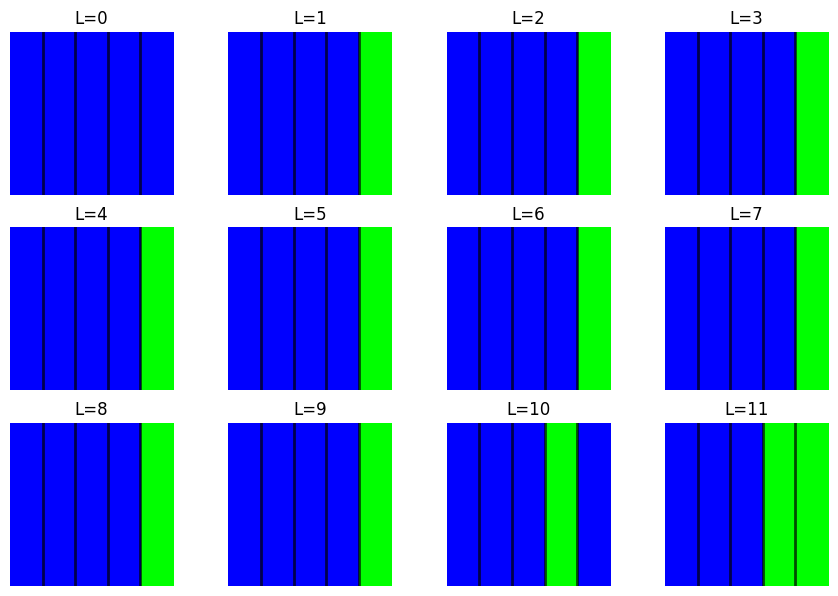

In [873]:
test_enc, test_lbl = create_data(records=12, classes=100_000, base=10)
show_batch(test_enc, labels=test_lbl, cmap='brg', columns=4)

# Model Architecture

In [874]:
def model_size(model: meat.NeatModule):
    return np.sum([param.numel() * param.element_size() for param in model.parameters()]) / (1024 ** 2)

def model_params(model: meat.NeatModule):
    return np.sum([param.numel() for param in model.parameters()])

In [901]:
class ConvNetwork(meat.NeatModule):
    def __init__(
        self, inputs: int, outputs: int, dim_size: int, kernel_size: int, seq_len: int, layers: int,
        vocab_size: int | None = None, groups=1, epsilon=1e-12, bias=True, device='cpu', dtype=torch.float32
    ):
        super().__init__()
        
        self.inputs         = inputs
        self.outputs        = outputs
        self.dim_size       = dim_size
        self.kernel_size    = kernel_size
        self.seq_len        = seq_len
        self.layers         = layers
        self.vocab_size     = vocab_size
        self.groups         = groups
        self.epsilon        = epsilon
        self.bias           = bias
        self.device         = device
        self.dtype          = dtype

        # Input projection
        sequence = [ # Expected shape(genomes, *batch_size, features=1, sequence)
            (
                mnn.Conv1d(inputs, dim_size, 1, bias=True, device=device, dtype=dtype) 
                if vocab_size is None else 
                mnn.Sequential(
                    mnn.Embedding(vocab_size, dim_size, device=device, dtype=dtype),
                    mnn.Transpose()
                )
            ),
            mnn.Conv1d(dim_size, dim_size, kernel_size, padding=-1, bias=bias, device=device, dtype=dtype),
            # TODO: Create custom NEAT MaxPooling that will be implemented here or use normal torch modules maybe
            #       or put on hold if deemed not necessary for this simple test
            # NOTE: mnn.Transpose(...), mnn.Permute(...)
            # TODO: Verify structuraly if normalization is necessary in first step or at all
            # mnn.GroupNorm(groups, dim_size, epsilon, True, bias=False, device=device, dtype=dtype),
            nn.SiLU(),
        ]
        # Deep neural network
        for layer_idx in range(layers):
            sequence.extend([ # Expected shape(genomes, *batch_size, dim_size, sequence)
                mnn.Conv1d(dim_size, dim_size, kernel_size, padding=-1, bias=bias, device=device, dtype=dtype),
                # TODO: Verify structuraly if groups should be added to convolution
                # mnn.GroupNorm(groups, dim_size, epsilon, True, bias=False, device=device, dtype=dtype),
                # TODO: Verify structuraly if normalization is done before or after activation or convolution
                nn.SiLU(),
            ])
        # Output projection
        sequence.extend([ # in=(genomes, *batch_size, dim_size, sequence) out=(genomes, *batch_size, classes)
            nn.Flatten(start_dim=-2),
            # NOTE: Average pooling removed - we now flatten the (dim_size, sequence) block directly and
            #       project the full flattened vector, so no information is averaged away.
            mnn.Linear(dim_size * seq_len, dim_size, bias=bias, device=device, dtype=dtype),
            nn.SiLU(),
            mnn.Linear(dim_size, outputs, bias=True, device=device, dtype=dtype),
        ])

        self.sequence = mnn.Sequential(*sequence)

    def forward(self, tensor: Tensor, keys: Union[int, list[int]] = None, verbose: int = None):
        tensor = self.sequence(tensor, keys=keys)
        return tensor

    def evaluate(self, tensor: Tensor, keys: Union[int, list[int]] = None, verbose: int = None):
        logits = self(tensor, keys=keys, verbose=verbose)
        return torch.argmax(logits, dim=-1)

    # TODO: Merge into .evaluate as 'deterministic' or not rather a separate method
    def guess(self, tensor, keys: Union[int, list[int]] = None):
        logits = self(tensor, keys=keys)
        dist = torch.distributions.Categorical(logits=logits)
        return dist.sample()


class LinNetwork(meat.NeatModule):
    """Fully-connected counterpart to ConvNetwork, used as a baseline to compare against."""

    def __init__(
        self, inputs: int, outputs: int, seq_len: int, dim_size: int, layers: int,
        vocab_size: int | None = None, bias=True, device='cpu', dtype=torch.float32
    ):
        super().__init__()

        self.inputs      = inputs
        self.outputs     = outputs
        self.seq_len     = seq_len
        self.dim_size    = dim_size
        self.layers      = layers
        self.vocab_size  = vocab_size
        self.bias        = bias
        self.device      = device
        self.dtype       = dtype

        # Input projection: 
        sequence = [
            # out=(genomes, *batch_size, seq_len, features=1)
            (
                mnn.Sequential(
                    mnn.Transpose(), 
                    mnn.Linear(inputs, dim_size, bias=True, device=device, dtype=dtype),
                )
                if vocab_size is None else
                mnn.Sequential(
                    mnn.Embedding(vocab_size, dim_size, device=device, dtype=dtype),
                )
            ),
            
            mnn.Linear(dim_size, dim_size, bias=bias, device=device, dtype=dtype),
            nn.SiLU(),
        ]
        
        # Deep neural network, matching ConvNetwork's `layers` count for a fair comparison
        for layer_idx in range(layers):
            sequence.extend([
                mnn.Linear(dim_size, dim_size, bias=bias, device=device, dtype=dtype),
                nn.SiLU(),
            ])
        
        # Output projection: flatten (features, sequence) into a single vector per record
        sequence.extend([
            nn.Flatten(start_dim=-2),
            mnn.Linear(dim_size * seq_len, dim_size, bias=bias, device=device, dtype=dtype),
            nn.SiLU(),
            mnn.Linear(dim_size, outputs, bias=True, device=device, dtype=dtype),
        ])

        self.sequence = mnn.Sequential(*sequence)

    def forward(self, tensor: Tensor, keys: Union[int, list[int]] = None, verbose: int = None):
        return self.sequence(tensor, keys=keys)

    def evaluate(self, tensor: Tensor, keys: Union[int, list[int]] = None, verbose: int = None):
        logits = self(tensor, keys=keys, verbose=verbose)
        return torch.argmax(logits, dim=-1)

    def guess(self, tensor, keys: Union[int, list[int]] = None):
        logits = self(tensor, keys=keys)
        dist = torch.distributions.Categorical(logits=logits)
        return dist.sample()


In [876]:
test_inputs = torch.randn(1, 10, 3, 16, dtype=DTYPE)
test_model = ConvNetwork(
    inputs=3, outputs=10, kernel_size=3, dim_size=64, seq_len=16,
    layers=2, bias=False, device='cpu', dtype=DTYPE
)
print(test_model)
print(f"Genomes={test_model.genome_num}, Parameters={model_params(test_model)}, Size={model_size(test_model):.4f} MB")
with torch.no_grad():
    test_outputs = test_model.evaluate(test_inputs, verbose=2)
    test_guess = test_model.guess(test_inputs)
    # test_model.save()
    # test_model.load()
test_outputs, test_guess, test_outputs.shape

ConvNetwork(
  (sequence): Sequential[NeatModule](
    (0): Conv1d[NeatModule](channels_in=3, channels_out=64, kernel_size=(1,), stride=1, padding=(0,), dilation=1, groups=1, bias=True, padding_mode=zeros)
    (1): Conv1d[NeatModule](channels_in=64, channels_out=64, kernel_size=(3,), stride=1, padding=(1,), dilation=1, groups=1, bias=False, padding_mode=zeros)
    (2): SiLU()
    (3): Conv1d[NeatModule](channels_in=64, channels_out=64, kernel_size=(3,), stride=1, padding=(1,), dilation=1, groups=1, bias=False, padding_mode=zeros)
    (4): SiLU()
    (5): Conv1d[NeatModule](channels_in=64, channels_out=64, kernel_size=(3,), stride=1, padding=(1,), dilation=1, groups=1, bias=False, padding_mode=zeros)
    (6): SiLU()
    (7): Flatten(start_dim=-2, end_dim=-1)
    (8): Linear[NeatModule](inputs=1024, outputs=64, bias=False)
    (9): SiLU()
    (10): Linear[NeatModule](inputs=64, outputs=10, bias=True)
  )
)
Genomes=None, Parameters=103306, Size=0.3941 MB


(tensor([[4, 6, 6, 1, 1, 6, 3, 4, 4, 6]]),
 tensor([[4, 6, 6, 1, 1, 6, 3, 4, 4, 6]]),
 torch.Size([1, 10]))

# Population creation

In [877]:
def create_population(
    module: NeatModule, genomes: int, config: Config = None, 
    reporter: bool = False, verbose: bool | int = False
):
    population = Population(genomes, module, config, init_rep=reporter, verbose=verbose)
    return population

In [878]:
test_population = create_population(ConvNetwork(1, 10, 16, 3, 64, 1), 20, reporter=True, verbose=2)
test_model = test_population.modules[0]
test_model.genome_num, test_model

Initialized genomes in  in 0.43s
Ran distance kernel in 0.02 s
Created distances cache in 0.41 s
Collected species representatives in 0.0 s
Filled species in 0.0 s
Updated species mapping in 0.0 s
Completed speciating in 0.41 s
Mean genetic distance 1.068, standard deviation 0.250, with 1 species


(20,
 ConvNetwork(
   (sequence): Sequential[NeatModule](
     (0): Conv1d[NeatModule](channels_in=1, channels_out=16, kernel_size=(1,), stride=1, padding=(0,), dilation=1, groups=1, bias=True, padding_mode=zeros)
     (1): Conv1d[NeatModule](channels_in=16, channels_out=16, kernel_size=(3,), stride=1, padding=(1,), dilation=1, groups=1, bias=True, padding_mode=zeros)
     (2): SiLU()
     (3): Conv1d[NeatModule](channels_in=16, channels_out=16, kernel_size=(3,), stride=1, padding=(1,), dilation=1, groups=1, bias=True, padding_mode=zeros)
     (4): SiLU()
     (5): Flatten(start_dim=-2, end_dim=-1)
     (6): Linear[NeatModule](inputs=1024, outputs=16, bias=True)
     (7): SiLU()
     (8): Linear[NeatModule](inputs=16, outputs=10, bias=True)
   )
 ))

# Initialization

In [879]:
RECORDS     = 50
SPLIT       = 0.80
CLASSES     = 27
BASE        = 3
NORMALIZE   = True
DISCRETE    = True
REVERSED    = False
SEQ_LEN     = math.ceil(round(math.log(CLASSES, BASE), 8))

In [880]:
GENOMES     = 50
CONFIG      = Config("binary", "tests")
CONFIG.genome.init_type                 = 'normal'
CONFIG.genome.weight_init_mean          = 0.0
CONFIG.genome.weight_init_std           = 0.15
CONFIG.genome.weight_min_value          = -math.inf
CONFIG.genome.weight_max_value          = +math.inf
CONFIG.genome.weight_mutate_power       = 0.09
CONFIG.genome.weight_mutate_rate        = 0.65
CONFIG.genome.weight_replace_rate       = 0.00
CONFIG.reproduction.min_species_size    = GENOMES
CONFIG.reproduction.purge               = 1
CONFIG.reproduction.survival_threshold  = 0.20
CONFIG.reproduction.clone_threshold     = 0.50
CONFIG.reproduction.darwin_multiplier   = 0.50
CONFIG.reproduction.elitism             = 0.33
CONFIG.species.compatibility_threshold  = math.inf
CONFIG.stagnation.max_stagnation        = 1
CONFIG.stagnation.species_elitism       = 1
print(f"Config path = {CONFIG.path}")
CONFIG.save()
CONFIG.load(2)

SCHEDULERS = [
    optim.scheduler.CosineAnnealing(CONFIG, 20, 0.01, ['weight_mutate_power', 'weight_init_std'], warm=True, log=True),
    # # optim.scheduler.CosineAnnealing(CONFIG, 10, 0.75, 'weight_mutate_rate', True, True),
    # optim.scheduler.CosineAnnealing(CONFIG, 50, 0.33, 'weight_replace_rate', True, True),
]

Config path = tests/binary.mnc.json
Created configuration 'GENERAL CONFIG' in NEAT Configuration binary.mnc.json
Created configuration 'GENOME CONFIG' in NEAT Configuration binary.mnc.json
Created configuration 'SPECIES CONFIG' in NEAT Configuration binary.mnc.json
Created configuration 'STAGNATION CONFIG' in NEAT Configuration binary.mnc.json
Created configuration 'REPRODUCTION CONFIG' in NEAT Configuration binary.mnc.json
fitness_criterion         = max
fitness_threshold         = inf
pop_size                  = 100
reset_on_extinction       = True
seed                      = 83096
Loaded configuration 'GENERAL CONFIG' in NEAT Configuration binary.mnc.json
weight_init_mean          = 0.0
weight_init_std           = 0.15
weight_max_value          = inf
weight_min_value          = -inf
weight_mutate_power       = 0.09
weight_mutate_rate        = 0.65
weight_replace_rate       = 0.0
weight_add_prob           = 0.25
weight_del_prob           = 0.01
param_epsilon             = 1e-12
compa

In [881]:
def get_records(genomes: int, split: float):
    assert 0 < split < 1
    records_train = round(RECORDS * split)
    records_eval = RECORDS - records_train
    assert records_train > 0 and records_eval > 0
    records = [
        create_data(l, CLASSES, BASE, REVERSED, NORMALIZE, DISCRETE, False, device='cpu', dtype=DTYPE)
        for l in [records_train, records_eval]
    ]
    
    def add_feature(tensor): return tensor.unsqueeze(-2)
    def nothing(tensor): return tensor

    # NOTE: The Conv1d input branch expects a (features, sequence) layout, so encodings get an
    #       extra singleton feature dim added. The Embedding input branch (used when DISCRETE=True)
    #       expects plain (sequence,) integer token ids instead, so we must NOT add that extra
    #       dim in the discrete case or the embedding lookup / downstream Conv1d shapes break.
    encoding_transform = nothing if DISCRETE else add_feature
    
    return tuple(
        tuple(
            g(t.unsqueeze(0).repeat_interleave(genomes, dim=0).to(DEVICE))
            for t, g in zip(d, [encoding_transform, nothing])
        )
        for d in records
    )

(train_inp, train_out), (eval_inp, eval_out) = train_data, eval_data = get_records(GENOMES, SPLIT)

In [882]:
train_inp[:4, :3], train_out[:4, :3], train_inp.shape, train_out.shape, eval_out.shape

(tensor([[[0, 0, 0],
          [0, 0, 1],
          [0, 0, 2]],
 
         [[0, 0, 0],
          [0, 0, 1],
          [0, 0, 2]],
 
         [[0, 0, 0],
          [0, 0, 1],
          [0, 0, 2]],
 
         [[0, 0, 0],
          [0, 0, 1],
          [0, 0, 2]]], dtype=torch.int32),
 tensor([[0, 1, 2],
         [0, 1, 2],
         [0, 1, 2],
         [0, 1, 2]], dtype=torch.int32),
 torch.Size([50, 40, 3]),
 torch.Size([50, 40]),
 torch.Size([50, 10]))

In [883]:
INPUTS      = 1
OUTPUTS     = CLASSES
EMBED_SIZE  = 32
KERNEL_SIZE = 3
# NOTE: FC_SIZE dependant on NoOfBits * DimSize
VOCAB_SIZE  = None if not DISCRETE else BASE
LAYERS      = 2
GROUPS      = 1
BIAS        = True
assert KERNEL_SIZE <= SEQ_LEN

In [884]:
CONV_MODEL = ConvNetwork(
    INPUTS, OUTPUTS, EMBED_SIZE, KERNEL_SIZE, SEQ_LEN, 
    LAYERS, VOCAB_SIZE, GROUPS, bias=BIAS,
    device=DEVICE, dtype=DTYPE
)
CONV_POPULATION = create_population(CONV_MODEL, GENOMES, CONFIG)
print(f"Genomes={CONV_MODEL.genome_num}, Parameters={model_params(CONV_MODEL)}, Size={model_size(CONV_MODEL):.4f} MB")
CONV_MODEL

Genomes=50, Parameters=670150, Size=2.5564 MB


ConvNetwork(
  (sequence): Sequential[NeatModule](
    (0): Sequential[NeatModule](
      (0): Embedding[NeatModule](vocab_size=3, dim_size=32, padding_idx=None)
      (1): Transpose(dim0=-1, dim1=-2)
    )
    (1): Conv1d[NeatModule](channels_in=32, channels_out=32, kernel_size=(3,), stride=1, padding=(1,), dilation=1, groups=1, bias=True, padding_mode=zeros)
    (2): SiLU()
    (3): Conv1d[NeatModule](channels_in=32, channels_out=32, kernel_size=(3,), stride=1, padding=(1,), dilation=1, groups=1, bias=True, padding_mode=zeros)
    (4): SiLU()
    (5): Conv1d[NeatModule](channels_in=32, channels_out=32, kernel_size=(3,), stride=1, padding=(1,), dilation=1, groups=1, bias=True, padding_mode=zeros)
    (6): SiLU()
    (7): Flatten(start_dim=-2, end_dim=-1)
    (8): Linear[NeatModule](inputs=96, outputs=32, bias=True)
    (9): SiLU()
    (10): Linear[NeatModule](inputs=32, outputs=27, bias=True)
  )
)

In [885]:
test_pred = CONV_MODEL.guess(eval_inp)
test_pred[:4, :3], test_pred.shape

(tensor([[23, 23, 20],
         [16, 12,  9],
         [13, 10,  6],
         [23,  1, 21]]),
 torch.Size([50, 10]))

# Train convolutional model

In [886]:
BATCH_SIZE = 256
USE_ACCURACY = False
EPOCHS = 400

In [887]:
def get_batches(records: int, batch_size: int = None, shuffle=False):
    if batch_size is None:
        batch_size = records
    assert records > 0
    if batch_size is None:
        batch_size = records
    else:
        assert batch_size > 0
        batch_size = min(batch_size, records)

    indices: list[int] = list(range(records))
    if shuffle:
        random.shuffle(indices)
    batch_indices: list[list[int]] = list()
    batch: list[int] = list()
    for i, index in enumerate(indices):
        batch.append(index)
        batch_is_filled = len(batch) == batch_size
        no_more_records = i == len(indices) - 1 and not batch_is_filled
        if batch_is_filled or no_more_records:
            batch_indices.append(batch)
            batch = list()

    return batch_indices

In [888]:
@torch.no_grad() # NOTE: Just in case parameters have gradients enabled
def get_accuracy(
    population: Population, inputs: Tensor, outputs: Tensor, 
    batch_size: int, deterministic: bool = True, verbose: bool | int = False,
    keys: Union[int, list[int], None] = None, mean: bool = False
):
    model = population.modules[0]
    if keys is not None and not isinstance(keys, (tuple, list)):
        keys = [keys]
    if keys is not None:
        mapping = population.get_mapping()
        key_indices = [mapping[key] for key in keys]
        inputs, outputs = inputs[key_indices], outputs[key_indices]

    torch.cuda.empty_cache()
    was_training = model.training
    if not was_training: model.eval()
    
    batch_indices = get_batches(inputs.shape[1], batch_size, False)
    summation = {index: 0 for index in range(len(outputs))}
    elements = {index: 0 for index in range(len(outputs))}
    # print(inputs.shape, outputs.shape, len(batch_indices), max([len(batch) for batch in batch_indices]))
    ts = clock.perf_counter()
    for step, batch in enumerate(batch_indices):
        with torch.no_grad():
            images = inputs[:, batch].to(model.device)
            target: Tensor = outputs[:, batch].to(model.device)
            if deterministic:
                prediction: torch.Tensor = model.evaluate(images, keys=keys)
            else:
                prediction: torch.Tensor = model.guess(images, keys=keys)
            total = prediction == target
            for index, (sub_total, sub_target) in enumerate(zip(total, target)):
                summation[index] += sub_total.sum().item()
                elements[index] += sub_target.numel()
        if verbose:
            eta(ts, step+1, len(batch_indices), f"Getting accuracy")
    if verbose:
        print(f"\nCalculated accuracy in {clock.perf_counter()-ts:.2f}s")

    accuracy = {index: s / e for (index, s), e in zip(summation.items(), elements.values())}
    
    torch.cuda.empty_cache()
    if was_training: model.train()
    
    if not mean:
        return np.max(list(accuracy.values())).item()
    else:
        return np.mean(list(accuracy.values())).item()


def report_accuracy(population: Population, label: str, batch_size: int = 512):
    """Prints/returns a (train, eval) x (deterministic, stochastic) x (max, mean) accuracy grid."""
    report = [
        [
            tuple(
                round(get_accuracy(population, *ds, batch_size, deterministic=trg_d, mean=trg_m), 2)
                for trg_m in [False, True]
            )
            for trg_d in [True, False]
        ]
        for ds in [train_data, eval_data]
    ]
    print(f"{label} accuracy [train, eval] x [deterministic, stochastic] x (max, mean): {report}")
    return report


In [889]:
def cross_entropy_loss(logits: Tensor, targets: Tensor):
    """
    Gets the cross entropy loss for genomes, given logits and targets.
    :param logits: Assumes last dimension is for logit probabilities.
    :param targets: Assumes last dimension is for target values.
    :return:
    """
    assert logits.ndim >= 2
    assert logits.ndim -1 == targets.ndim
    genome_num, classes_num = logits.shape[0], logits.shape[-1]
    return F.cross_entropy(
        logits.view(genome_num, -1, classes_num).mT,
        targets.view(genome_num, -1).long(),
        reduction="none"
    ).mean(dim=-1)

# Sanity check against the reference (unbatched) implementation
test_classes    = 10
test_genomes    = 11
test_batches    = 32
test_seq_len    = 4
test_device     = 'cpu' if torch.cuda.is_available() else 'cpu'
test_tensor_logt    = torch.normal(0, 1e1, (test_genomes, test_batches, test_seq_len, test_classes)).to(test_device)
test_tensor_targ    = torch.randint(0, test_classes, (test_genomes, test_batches, test_seq_len)).to(test_device)
test_losses         = cross_entropy_loss(test_tensor_logt, test_tensor_targ)
test_losses_normal  = F.cross_entropy(test_tensor_logt.permute(0, -1, 1, 2), test_tensor_targ, reduction='none').mean(dim=[-2, -1])

assert torch.allclose(test_losses, test_losses_normal), "cross_entropy_loss diverges from the reference implementation"
print("cross_entropy_loss matches F.cross_entropy (reference) ✔")


cross_entropy_loss matches F.cross_entropy (reference) ✔


In [890]:
def evaluate(population: meat.Population, **options):
    model = population.modules[0]
    batch_size = options.get('batch_size', BATCH_SIZE)
    use_accuracy = options.get('use_accuracy', USE_ACCURACY)
    inputs, outputs = (t.clone() for t in [train_inp, train_out])

    # -------------------- Fetching -------------------- #
    losses_plot: list[float] = options['losses']
    accuracy_plot: list[float] = options['accuracies']
    genomes: list[int] = options['genomes']

    # -------------------- Evaluating -------------------- #
    records = inputs.shape[1]
    batches = get_batches(records, batch_size, shuffle=False)
    losses = []
    correct_counts = []
    total_counts = []
    epoch = options['epoch']
    for step, batch in enumerate(batches):
        batch_inputs = inputs[:, batch]
        batch_predictions = model(batch_inputs)
        batch_targets = outputs[:, batch]
        if step == 0 and epoch == 0:
            print(f"\nConvolutee: ({batch_inputs.shape})")
            print(f"Predictions: {batch_predictions[:2]} ({batch_predictions.shape})")
            print(f"Targets: {batch_targets[:2]} ({batch_targets.shape})")
        batch_losses = cross_entropy_loss(batch_predictions, batch_targets)
        if step == 0 and epoch == 0:
            print(f"Batch Loss = {batch_losses[:3]} ({batch_losses.shape})")
        losses.append(batch_losses)
        if use_accuracy:
            # genome_num, *batch_dims -> flatten everything after genome dim to count matches per genome
            genome_num = batch_predictions.shape[0]
            batch_preds_cls = torch.argmax(batch_predictions, dim=-1).view(genome_num, -1)
            batch_targets_flat = batch_targets.view(genome_num, -1)
            correct_counts.append((batch_preds_cls == batch_targets_flat).sum(dim=-1))
            total_counts.append(batch_targets_flat.shape[-1])
    losses = torch.stack(losses, dim=0).mean(dim=0)

    # -------------------- Setting scores -------------------- #
    if use_accuracy:
        # Fitness = accuracy (higher is better), no need to negate like we do for loss.
        accuracies_per_genome = torch.stack(correct_counts, dim=0).sum(dim=0).float() / sum(total_counts)
        scores = accuracies_per_genome.cpu().numpy()
    else:
        scores = -losses.cpu().numpy()
    for score, gid in zip(scores, population.get_mapping(consolidated=True)):
        population.genomes[gid].fitness = score
    ranking = list(sorted(population.genomes.items(), key=lambda item: item[1].fitness, reverse=True))
    best_genome = ranking[0][1]
    best_key = best_genome.key
    best_score = best_genome.fitness

    # -------------------- Logging -------------------- #
    losses_plot.append(losses.mean().cpu().item() + losses.std().cpu().item())
    accuracy_plot.append(get_accuracy(population, inputs, outputs, BATCH_SIZE, keys=best_key))
    genomes.append(best_key)


In [891]:
report_accuracy(CONV_POPULATION, "ConvNetwork (untrained baseline)")


ConvNetwork (untrained baseline) accuracy [train, eval] x [deterministic, stochastic] x (max, mean): [[(0.1, 0.04), (0.12, 0.04)], [(0.1, 0.03), (0.3, 0.04)]]


[[(0.1, 0.04), (0.12, 0.04)], [(0.1, 0.03), (0.3, 0.04)]]

In [892]:
def train(
    population: Population, epochs: int, batch_size: int = None, show=True, 
    schedulers: list = [], checkpoints=5, use_accuracy: bool = None
):
    model = population.modules[0]
    torch.cuda.empty_cache()
    losses: list[float]     = []
    accuracies: list[float] = []
    genomes: list[int]      = []
    if use_accuracy is None:
        use_accuracy = USE_ACCURACY

    ts = clock.perf_counter()
    for scheduler in schedulers: scheduler.reset()
    try:
        for epoch in range(epochs):
            population.run(
                evaluate, 1,
                losses=losses, accuracies=accuracies,
                genomes=genomes, epoch=epoch,
                batch_size=batch_size,
                use_accuracy=use_accuracy,
                verbose=False
            )
            for scheduler in schedulers: scheduler.step()
            eta(ts, epoch+1, epochs, f"NEAT training: loss={population.best_genome.fitness:.4f}")
    except KeyboardInterrupt as e:
        print(CM("Terminated", Fore.LIGHTRED_EX))
    print(f"finished NEAT training in {clock.perf_counter() - ts:.1f}s")

    if show:
        plt.close()
        axes = plt.subplots(1, 3, figsize=(14.4, 5.4))[1]
        axes = axes.flatten()
        axes[0].plot(losses)
        axes[0].set_title('Loss')
        axes[1].plot(accuracies)
        axes[1].set_title('Accuracy')
        axes[2].plot(genomes)
        axes[2].set_title('Genome')

    torch.cuda.empty_cache()
    return {"losses": losses, "accuracies": accuracies, "genomes": genomes}



Convolutee: (torch.Size([50, 40, 3]))
Predictions: tensor([[[ 0.1245, -0.0788, -0.1379,  ..., -0.0893,  0.2867,  0.2327],
         [ 0.1397, -0.1009, -0.0674,  ..., -0.1004,  0.2582,  0.2342],
         [ 0.1255, -0.0722, -0.1268,  ..., -0.1049,  0.2861,  0.2451],
         ...,
         [ 0.1268, -0.1190, -0.0812,  ..., -0.1145,  0.2737,  0.2363],
         [ 0.1134, -0.0832, -0.1449,  ..., -0.1174,  0.3019,  0.2446],
         [ 0.1335, -0.1032, -0.1267,  ..., -0.1218,  0.2892,  0.2241]],

        [[-0.2590,  0.2234, -0.0578,  ..., -0.2314,  0.1910, -0.1160],
         [-0.2551,  0.2128, -0.0447,  ..., -0.2270,  0.1836, -0.0705],
         [-0.2862,  0.2348, -0.0534,  ..., -0.2293,  0.1881, -0.0868],
         ...,
         [-0.2645,  0.2139, -0.0394,  ..., -0.2192,  0.2151, -0.0557],
         [-0.2978,  0.2375, -0.0496,  ..., -0.2214,  0.2215, -0.0694],
         [-0.2547,  0.2269, -0.0126,  ..., -0.1939,  0.2431, -0.0662]]]) (torch.Size([50, 40, 27]))
Targets: tensor([[ 0,  1,  2,  3,  4,

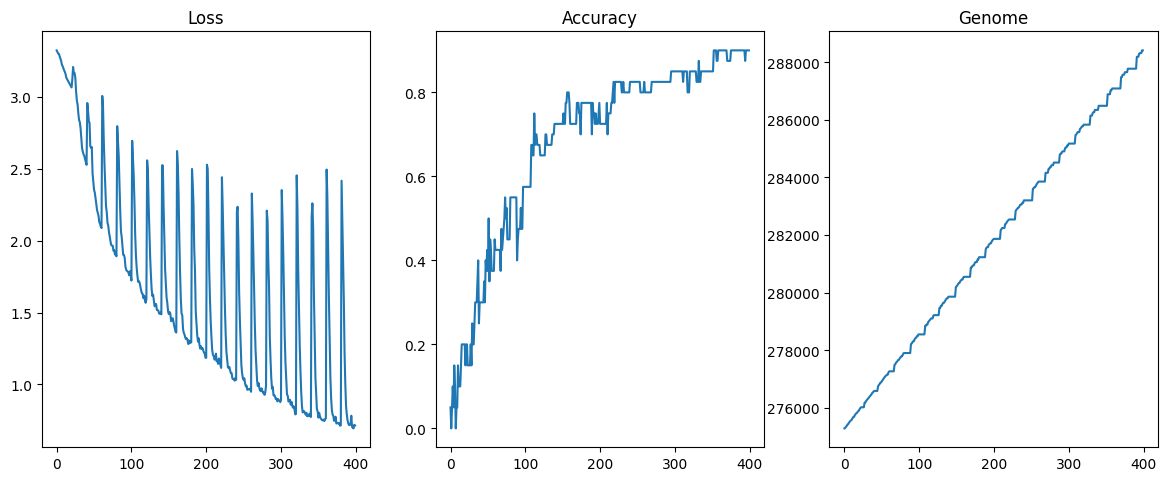

In [893]:
conv_history = train(CONV_POPULATION, EPOCHS, schedulers=SCHEDULERS, use_accuracy=USE_ACCURACY)

# Evaluation

In [894]:
report_accuracy(CONV_POPULATION, "ConvNetwork (trained)")


ConvNetwork (trained) accuracy [train, eval] x [deterministic, stochastic] x (max, mean): [[(0.93, 0.88), (0.78, 0.59)], [(1.0, 1.0), (1.0, 0.74)]]


[[(0.93, 0.88), (0.78, 0.59)], [(1.0, 1.0), (1.0, 0.74)]]

In [895]:
def get_indices(
    population: Population, images: Tensor, labels: Tensor, 
    include: Union[int, list[int]] = None, faulty: int = False, correct: int = False, 
    shuffle=True, keys: Union[int, list[int]] = None
):
    model = population.modules[0]
    faulty_enabled, correct_enabled = bool(faulty), bool(correct)
    if isinstance(include, (int, float)):
        include = [include]
    if keys is not None and not isinstance(keys, (tuple, list)):
        keys = [keys]

    mapping = population.get_mapping()
    indices = list(range(len(images))) if keys is None else [mapping[key] for key in keys]
    images, labels = images[indices], labels[indices]

    error_indices = []
    if faulty_enabled:
        if isinstance(faulty, bool):
            faulty = 64
        with torch.no_grad():
            for batch in get_batches(labels.shape[1], faulty, False):
                pred = model.evaluate(images[:, batch].to(model.device), keys=keys)
                mismatched = (pred != labels[:, batch].to(model.device)).movedim(0, 1)  # (batch, genomes)
                for index, errored in zip(batch, mismatched):
                    if torch.any(errored):
                        error_indices.append(index)
        print(f"Found {len(error_indices)} record predictions with errors")

    valid_indices = []
    if correct_enabled:
        if isinstance(correct, bool):
            correct = 64
        with torch.no_grad():
            for batch in get_batches(labels.shape[1], correct, False):
                pred = model.evaluate(images[:, batch].to(model.device), keys=keys)
                matched = (pred == labels[:, batch].to(model.device)).movedim(0, 1)  # (batch, genomes)
                for index, is_correct in zip(batch, matched):
                    if torch.any(is_correct):
                        valid_indices.append(index)
        print(f"Found {len(valid_indices)} valid record predictions ")

    indices_filtered = []
    no_type = not correct_enabled and not faulty_enabled
    for g_labels in labels.cpu():
        for x, record in enumerate(g_labels.cpu().tolist()):
            record_needed = include is None or record in include
            spec_type = x in error_indices or x in valid_indices
            if record_needed and (spec_type or no_type):
                indices_filtered.append(x)
    indices_filtered = list(set(indices_filtered))
    if shuffle:
        random.shuffle(indices_filtered)
    if len(indices_filtered) > 0:
        return indices_filtered
    else:
        raise ValueError(f"No indices available")


In [896]:
test_records = 24
CONV_MODEL.eval();

In [897]:
train_indices = get_indices(CONV_POPULATION, train_inp, train_out, faulty=None, keys=CONV_POPULATION.best_genome.key)
len(train_indices)

40

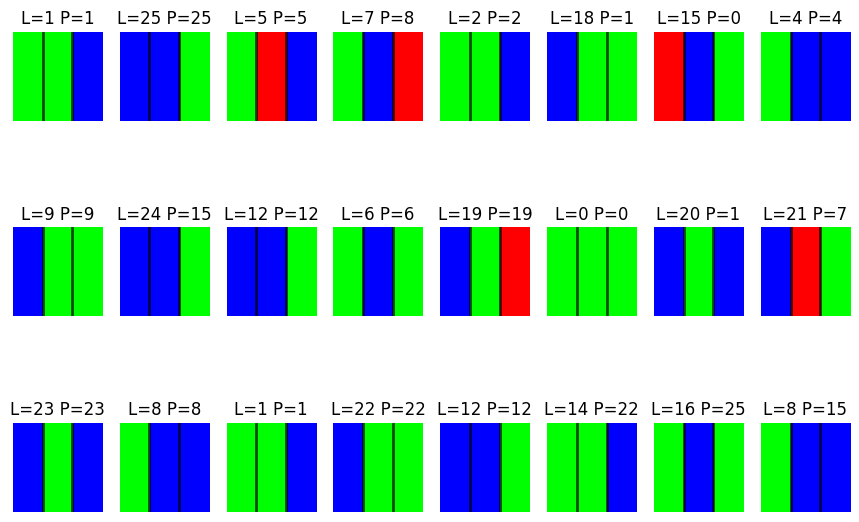

In [898]:
with torch.no_grad():
    random.shuffle(train_indices)
    test_indices = train_indices[:test_records]
    test_labels = CONV_MODEL.guess(train_inp[0, test_indices].unsqueeze(0).to(DEVICE), keys=CONV_POPULATION.best_genome.key)
show_batch(train_inp[0, test_indices], test_labels[0], train_out[0, test_indices], cmap='brg_r')

In [903]:
eval_indices = get_indices(CONV_POPULATION, eval_inp, eval_out, faulty=None, correct=False)
len(eval_indices)

10

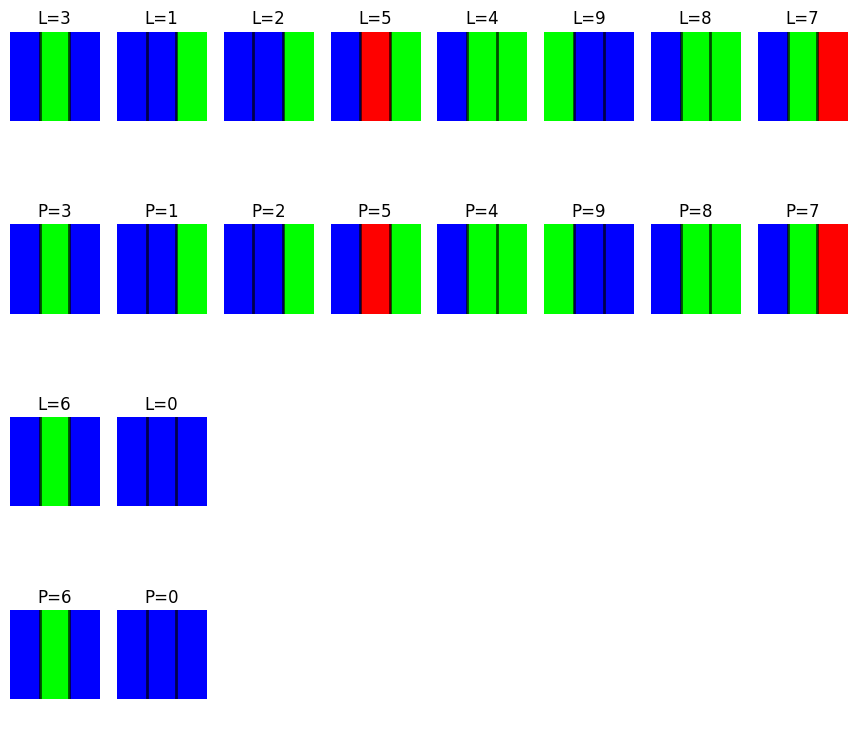

In [904]:
with torch.no_grad():
    random.shuffle(eval_indices)
    test_indices = eval_indices[:test_records]
    test_labels = CONV_MODEL.evaluate(eval_inp[0, test_indices].unsqueeze(0).to(DEVICE), keys=CONV_POPULATION.best_genome.key)
show_batch(
    eval_inp[0, test_indices], test_labels[0], eval_out[0, test_indices], 
    cmap='brg', size=(480, 1080),
    compare=True, base=BASE, reverse=REVERSED, normalize=NORMALIZE, discrete=DISCRETE,
)

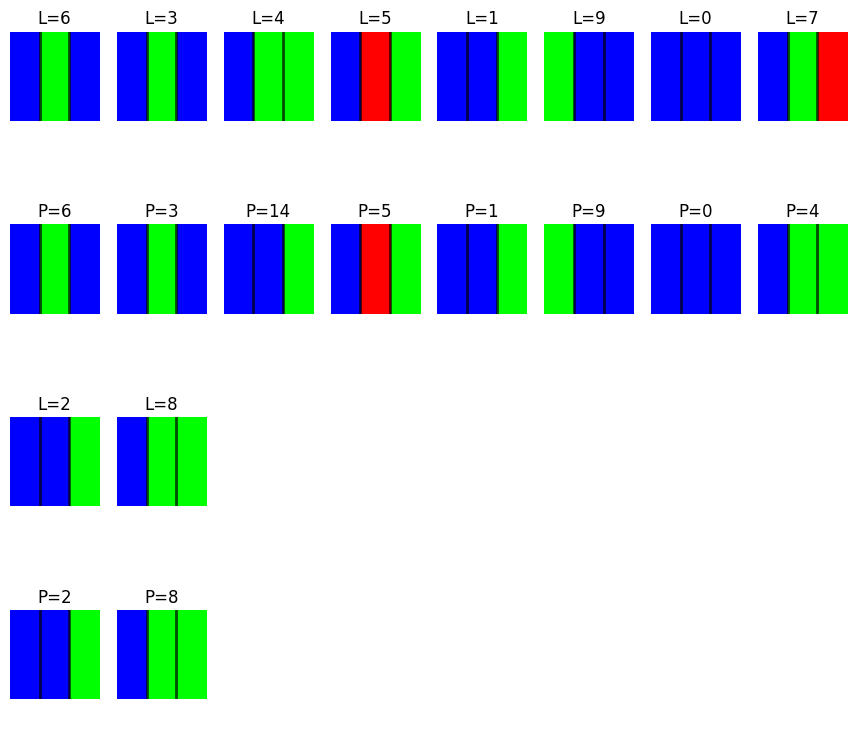

In [905]:
with torch.no_grad():
    random.shuffle(eval_indices)
    test_indices = eval_indices[:test_records]
    test_labels = CONV_MODEL.guess(eval_inp[0, test_indices].unsqueeze(0).to(DEVICE), keys=CONV_POPULATION.best_genome.key)
show_batch(
    eval_inp[0, test_indices], test_labels[0], eval_out[0, test_indices], 
    cmap='brg', size=(480, 1080),
    compare=True, base=BASE, reverse=REVERSED, normalize=NORMALIZE, discrete=DISCRETE,
)

# Linear comparison

In [906]:
LIN_MODEL = LinNetwork(
    INPUTS, OUTPUTS, SEQ_LEN, round(EMBED_SIZE*1.25),
    LAYERS, VOCAB_SIZE, bias=BIAS,
    device=DEVICE, dtype=DTYPE
)
LIN_POPULATION = create_population(LIN_MODEL, GENOMES, CONFIG)
print(f"Genomes={LIN_MODEL.genome_num}, Parameters={model_params(LIN_MODEL)}, Size={model_size(LIN_MODEL):.4f} MB")
LIN_MODEL


Genomes=50, Parameters=549350, Size=2.0956 MB


LinNetwork(
  (sequence): Sequential[NeatModule](
    (0): Sequential[NeatModule](
      (0): Embedding[NeatModule](vocab_size=3, dim_size=40, padding_idx=None)
    )
    (1): Linear[NeatModule](inputs=40, outputs=40, bias=True)
    (2): SiLU()
    (3): Linear[NeatModule](inputs=40, outputs=40, bias=True)
    (4): SiLU()
    (5): Linear[NeatModule](inputs=40, outputs=40, bias=True)
    (6): SiLU()
    (7): Flatten(start_dim=-2, end_dim=-1)
    (8): Linear[NeatModule](inputs=120, outputs=40, bias=True)
    (9): SiLU()
    (10): Linear[NeatModule](inputs=40, outputs=27, bias=True)
  )
)

In [907]:
report_accuracy(LIN_POPULATION, "LinNetwork (untrained baseline)")


LinNetwork (untrained baseline) accuracy [train, eval] x [deterministic, stochastic] x (max, mean): [[(0.12, 0.04), (0.1, 0.03)], [(0.1, 0.04), (0.2, 0.04)]]


[[(0.12, 0.04), (0.1, 0.03)], [(0.1, 0.04), (0.2, 0.04)]]


Convolutee: (torch.Size([50, 40, 3]))
Predictions: tensor([[[-0.1410,  0.1083, -0.1463,  ...,  0.1897, -0.2534, -0.2945],
         [-0.1244,  0.0985, -0.1437,  ...,  0.1875, -0.2460, -0.2903],
         [-0.1251,  0.1076, -0.1173,  ...,  0.2025, -0.2612, -0.3020],
         ...,
         [-0.1214,  0.0982, -0.1390,  ...,  0.1975, -0.2483, -0.2836],
         [-0.1219,  0.1073, -0.1122,  ...,  0.2123, -0.2631, -0.2953],
         [-0.1416,  0.1103, -0.1272,  ...,  0.1840, -0.2666, -0.2838]],

        [[ 0.0065,  0.0251,  0.1296,  ..., -0.2159, -0.0142,  0.2705],
         [ 0.0141,  0.0286,  0.1333,  ..., -0.2121, -0.0136,  0.2654],
         [ 0.0141,  0.0218,  0.1407,  ..., -0.2051, -0.0232,  0.2561],
         ...,
         [ 0.0137,  0.0273,  0.1343,  ..., -0.2059, -0.0167,  0.2599],
         [ 0.0138,  0.0205,  0.1416,  ..., -0.1991, -0.0265,  0.2507],
         [ 0.0048,  0.0232,  0.1322,  ..., -0.2180, -0.0222,  0.2754]]]) (torch.Size([50, 40, 27]))
Targets: tensor([[ 0,  1,  2,  3,  4,

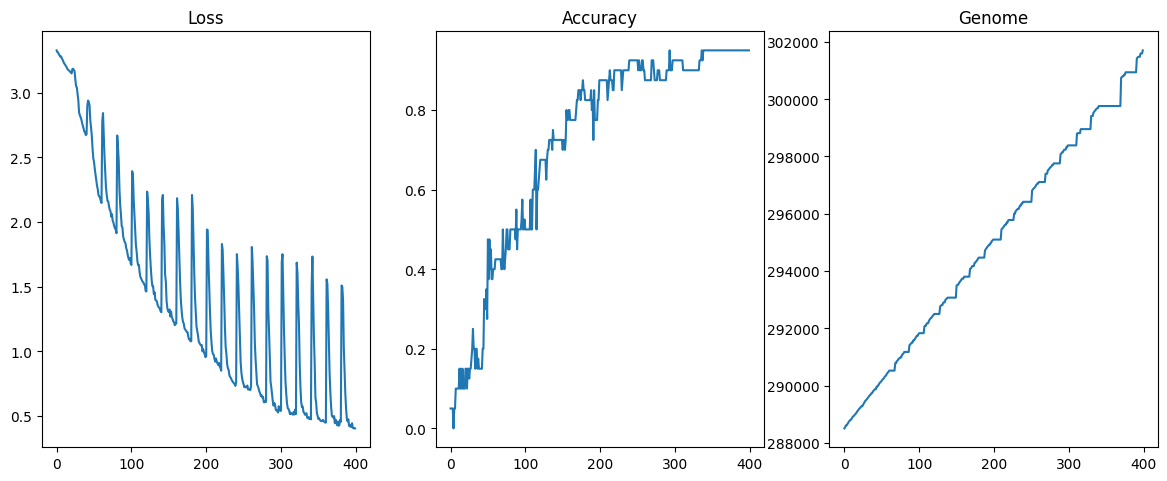

In [908]:
lin_history = train(LIN_POPULATION, EPOCHS, schedulers=SCHEDULERS, use_accuracy=USE_ACCURACY)

In [909]:
report_accuracy(LIN_POPULATION, "LinNetwork (trained)")


LinNetwork (trained) accuracy [train, eval] x [deterministic, stochastic] x (max, mean): [[(0.97, 0.95), (0.85, 0.76)], [(1.0, 1.0), (1.0, 0.8)]]


[[(0.97, 0.95), (0.85, 0.76)], [(1.0, 1.0), (1.0, 0.8)]]

## ConvNetwork vs. LinNetwork
Both models were trained for the same number of epochs, with the same population size, config and
mutation-rate schedulers, so the loss/accuracy curves below are directly comparable.

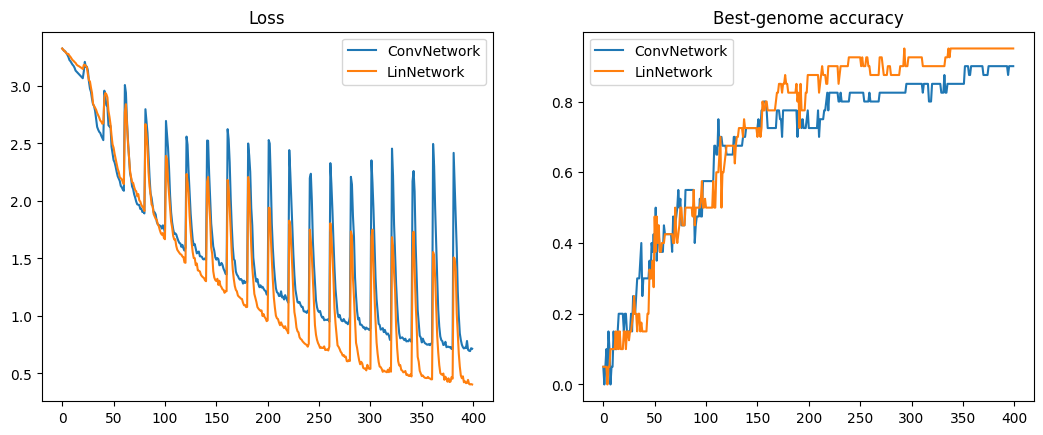

ConvNetwork params = 670150, LinNetwork params = 549350


In [910]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))
axes[0].plot(conv_history["losses"], label="ConvNetwork")
axes[0].plot(lin_history["losses"], label="LinNetwork")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(conv_history["accuracies"], label="ConvNetwork")
axes[1].plot(lin_history["accuracies"], label="LinNetwork")
axes[1].set_title("Best-genome accuracy")
axes[1].legend()
plt.show()

print(f"ConvNetwork params = {model_params(CONV_MODEL)}, LinNetwork params = {model_params(LIN_MODEL)}")


Current observations and conclusions


1. Lack of normalization, at least for simple models like this, seems to work better. Possibly due to the somewhat stochastic/randomized nature of fitting the weights, making it easier to find solutions even with the raw/un-normalized tensors, unlike with backprop.
2. Reduction of loss, especially on the convolutional models, is highly dependant on weight initialization range and weight mutation parameters, and seems to scale with the dimension size of layers. When too high, reduction is difficult since no back-propagation. When too low, it seems to take extremly long. 
3. With bias disabled, the models seem to reduce the loss better. Might just be due less parameters involved. Recent versions of NEAT generates values of weight and bias with the same constant, unlike older versions (ie. All model parameters are considered weights). So it must be easier to adjust weights alone when its the only direct benefactor to the mutate constant than with biases that typically need a separate constant.
4. Linear model has higher accuracy most of the time. Most probably due to how simple the example and patterns are
5. Models seem to converge better on discrete states with embedding layers rather than continuous states